# Insurance Dataset — End-to-End Data Science Project

**Note on scope:** Only one dataset (`insurance.csv`) was uploaded, so this notebook performs the
complete workflow on that single dataset. The dataset has a natural **regression target**
(`charges`) and no natural classification target, so for the classification section we use
`smoker` (yes/no) as the classification target — a genuinely categorical column already present
in the data. This is called out again in Part 1 and Part 6/7.

---
# Part 1 — Data Understanding


In [41]:
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_STATE = 42


In [42]:
# Load the dataset
df = pd.read_csv('insurance.csv')
print("First 5 records:")
df.head()


First 5 records:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [43]:
print("Last 5 records:")
df.tail()


Last 5 records:


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


## Understand the dataset

In [44]:
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (1338, 7)


In [45]:
print("Columns:", list(df.columns))


Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [46]:
print("Data types:")
df.dtypes


Data types:


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [47]:
print("Dataset info:")
df.info()


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [48]:
print("Statistical summary (numerical):")
df.describe()


Statistical summary (numerical):


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [49]:
print("Statistical summary (categorical):")
df.describe(include='object')


Statistical summary (categorical):


C:\Users\AC\AppData\Local\Temp\ipykernel_10188\2507892247.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [50]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Number of rows           :", df.shape[0])
print("Number of columns        :", df.shape[1])
print("Number of numerical features  :", len(num_cols), "->", num_cols)
print("Number of categorical features:", len(cat_cols), "->", cat_cols)
print("Target variable (regression)     : charges (continuous -> predict medical insurance cost)")
print("Target variable (classification) : smoker (binary yes/no -> used only for the classification section)")


C:\Users\AC\AppData\Local\Temp\ipykernel_10188\259719158.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


Number of rows           : 1338
Number of columns        : 7
Number of numerical features  : 4 -> ['age', 'bmi', 'children', 'charges']
Number of categorical features: 3 -> ['sex', 'smoker', 'region']
Target variable (regression)     : charges (continuous -> predict medical insurance cost)
Target variable (classification) : smoker (binary yes/no -> used only for the classification section)


**Observations**
- The dataset has 1338 rows and 7 columns (after removing the header line count discrepancy from any duplicates, see Part 2).
- Numerical features: `age`, `bmi`, `children`, `charges`.
- Categorical features: `sex`, `smoker`, `region`.
- `charges` is the natural **regression** target (what insurers want to predict).
- `smoker` is used as the **classification** target since there is no other natural binary/multi-class label in this dataset.


---
# Part 2 — Data Cleaning
## Missing Values


In [51]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct.round(2)})
missing_df


,Missing Count,Missing %
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


No missing values are present in this dataset, so no imputation is required. The cell below is
included as a general-purpose technique that would run safely even if missing values existed
(median for numeric columns, mode for categorical columns) — it will simply do nothing here.

In [52]:
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

print("Missing values after handling:")
df.isnull().sum().sum()


Missing values after handling:


np.int64(0)

## Duplicate Values

In [53]:
dup_count = df.duplicated().sum()
print("Number of duplicate rows:", dup_count)
df[df.duplicated(keep=False)]


Number of duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [54]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (1337, 7)


## Incorrect Data Types

In [55]:
print(df.dtypes)
# 'children' is a whole-number count -> keep as int (already int64 typically).
# 'sex', 'smoker', 'region' are categorical strings -> convert to pandas 'category' dtype for efficiency & clarity.
for c in ['sex', 'smoker', 'region']:
    df[c] = df[c].astype('category')

df['children'] = df['children'].astype(int)
df.dtypes


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object

## Unique Values of Categorical Columns

In [56]:
for c in ['sex', 'smoker', 'region']:
    print(f"--- {c} ---")
    print(df[c].value_counts())
    print("Unique values:", df[c].unique().tolist())
    print()


--- sex ---
sex
male      675
female    662
Name: count, dtype: int64
Unique values: ['female', 'male']

--- smoker ---
smoker
no     1063
yes     274
Name: count, dtype: int64
Unique values: ['yes', 'no']

--- region ---
region
southeast    364
southwest    325
northeast    324
northwest    324
Name: count, dtype: int64
Unique values: ['southwest', 'southeast', 'northwest', 'northeast']



---
# Part 3 — Exploratory Data Analysis (EDA)
## Univariate Analysis — Numerical Features


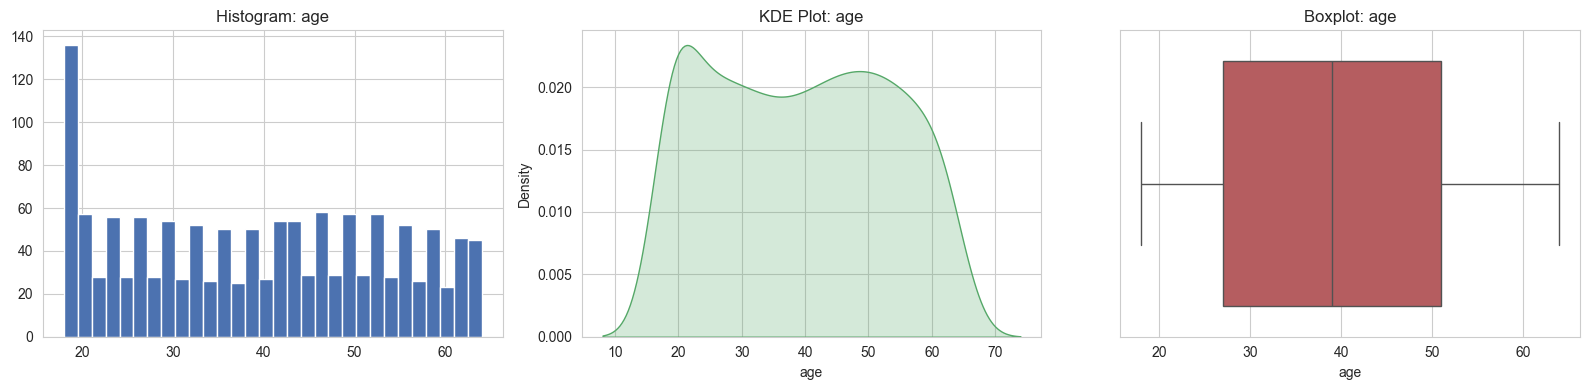

age: skew=0.05, mean=39.22, median=39.00



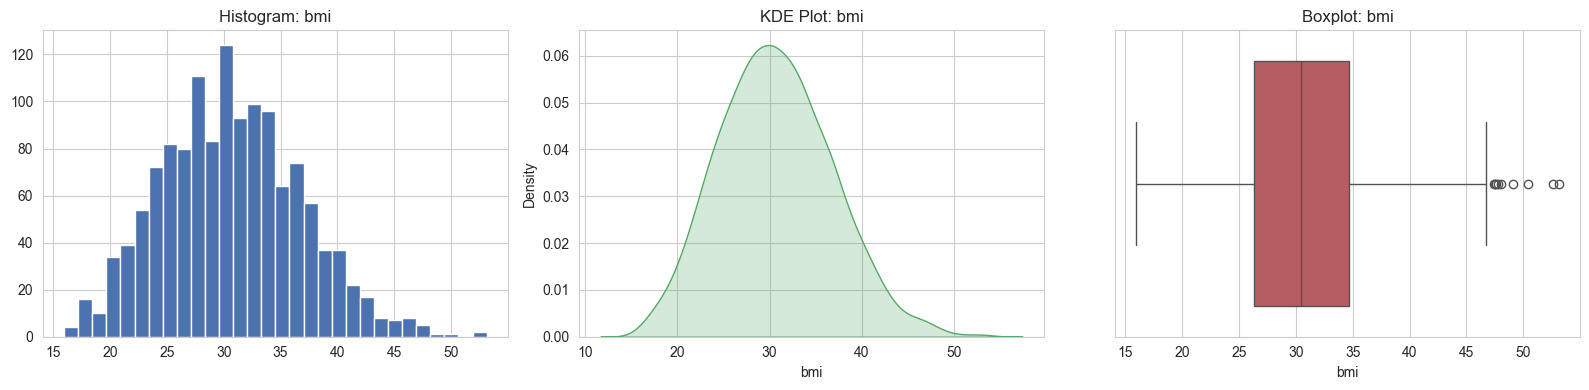

bmi: skew=0.28, mean=30.66, median=30.40



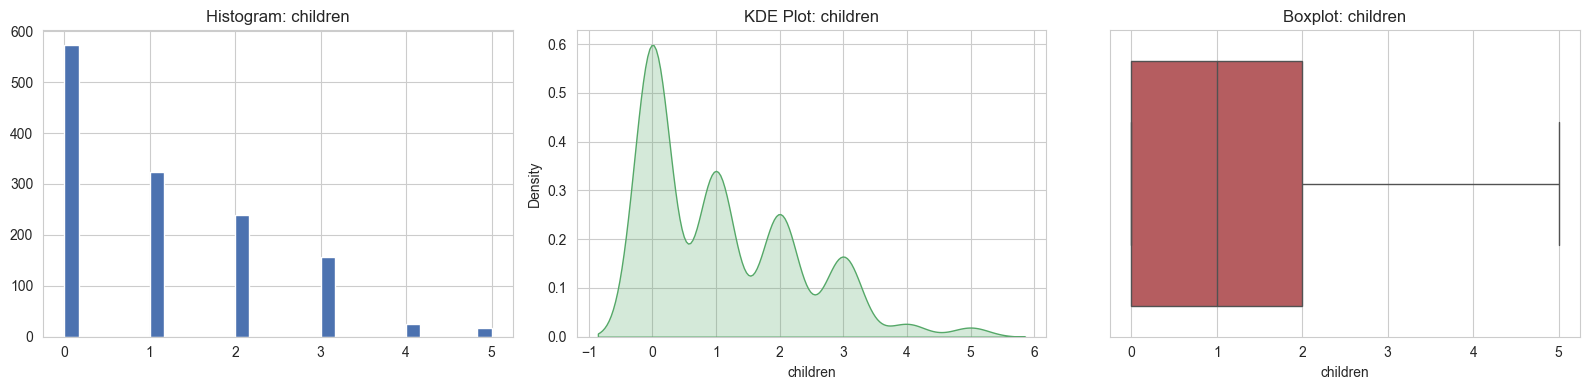

children: skew=0.94, mean=1.10, median=1.00



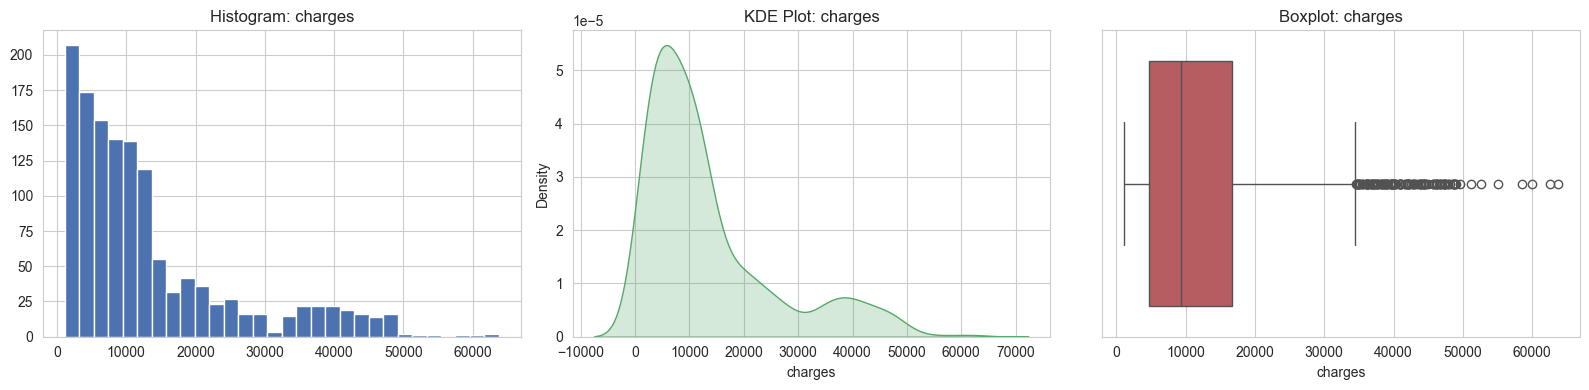

charges: skew=1.52, mean=13279.12, median=9386.16



In [57]:
numerical_features = ['age', 'bmi', 'children', 'charges']

for col in numerical_features:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].hist(df[col], bins=30, color='#4C72B0', edgecolor='white')
    axes[0].set_title(f'Histogram: {col}')

    sns.kdeplot(df[col], ax=axes[1], fill=True, color='#55A868')
    axes[1].set_title(f'KDE Plot: {col}')

    sns.boxplot(x=df[col], ax=axes[2], color='#C44E52')
    axes[2].set_title(f'Boxplot: {col}')

    plt.tight_layout()
    plt.show()

    print(f"{col}: skew={df[col].skew():.2f}, mean={df[col].mean():.2f}, median={df[col].median():.2f}\n")


**Interpretation of distributions**
- **age**: Fairly uniform spread across the adult range (18–64), no strong skew, no outliers in the boxplot.
- **bmi**: Approximately normal/bell-shaped distribution centered around 30, with a small number of high-BMI outliers on the right tail.
- **children**: Discrete, right-skewed — most policyholders have 0–2 children, few have 4–5.
- **charges**: Strongly right-skewed with a long tail — most people have moderate charges, but a subgroup (largely smokers) has very high charges, producing many boxplot outliers.


## Univariate Analysis — Categorical Features

C:\Users\AC\AppData\Local\Temp\ipykernel_10188\798966471.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=order, palette='viridis')


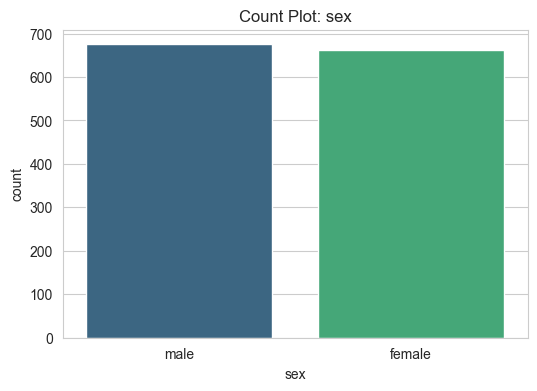

C:\Users\AC\AppData\Local\Temp\ipykernel_10188\798966471.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=order, palette='viridis')


sex
male      675
female    662
Name: count, dtype: int64
Most frequent category in 'sex': male



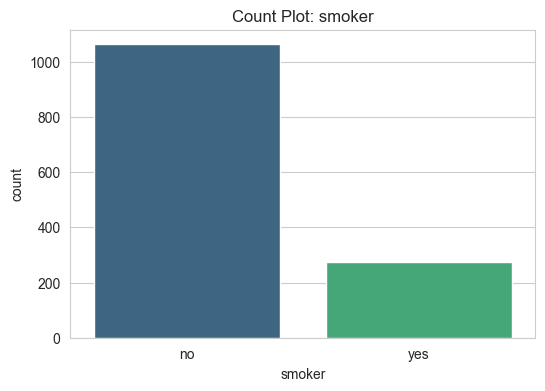

smoker
no     1063
yes     274
Name: count, dtype: int64
Most frequent category in 'smoker': no



C:\Users\AC\AppData\Local\Temp\ipykernel_10188\798966471.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=order, palette='viridis')


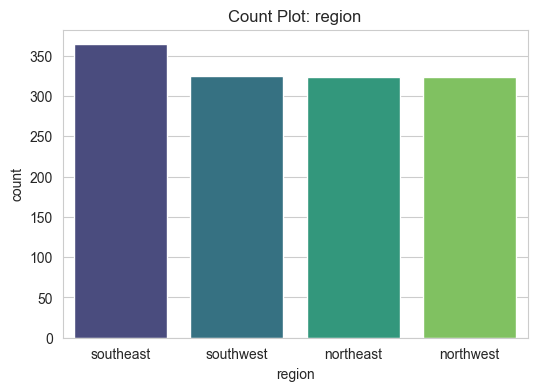

region
southeast    364
southwest    325
northeast    324
northwest    324
Name: count, dtype: int64
Most frequent category in 'region': southeast



In [58]:
categorical_features = ['sex', 'smoker', 'region']

for col in categorical_features:
    plt.figure(figsize=(6, 4))
    order = df[col].value_counts().index
    sns.countplot(x=df[col], order=order, palette='viridis')
    plt.title(f'Count Plot: {col}')
    plt.show()
    print(df[col].value_counts())
    print(f"Most frequent category in '{col}': {df[col].value_counts().idxmax()}\n")


**Interpretation**
- **sex**: Roughly balanced between male and female policyholders.
- **smoker**: Strongly imbalanced — the large majority are non-smokers, which will matter for the classification models later (class imbalance).
- **region**: Fairly evenly distributed across the four US regions (southeast slightly higher).


## Bivariate Analysis — For Regression (target = `charges`)

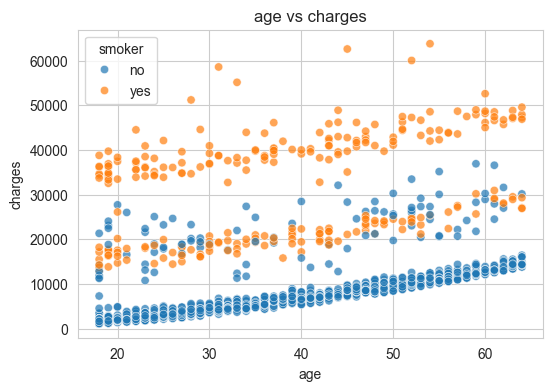

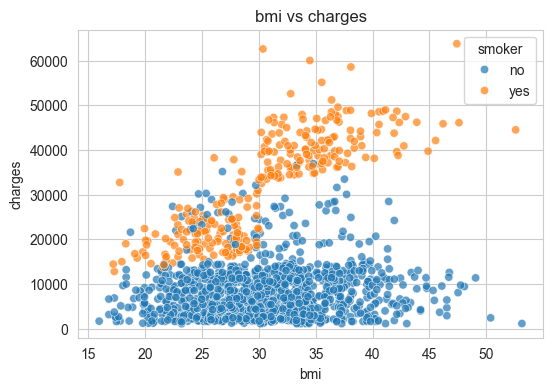

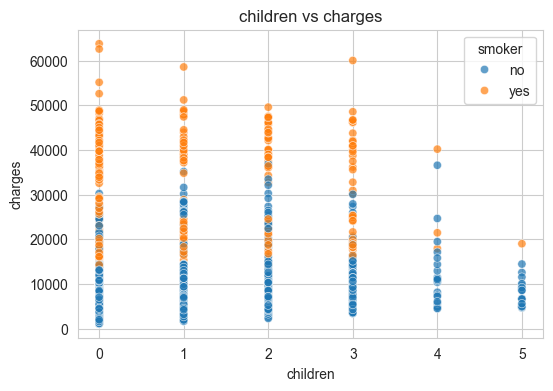

In [59]:
for col in ['age', 'bmi', 'children']:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y='charges', hue='smoker', alpha=0.7)
    plt.title(f'{col} vs charges')
    plt.show()


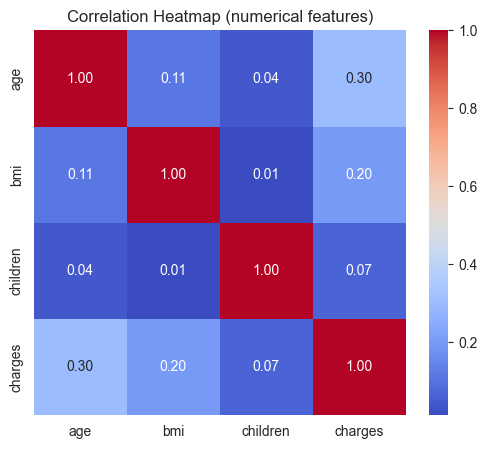

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


In [60]:
plt.figure(figsize=(6, 5))
corr = df[numerical_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (numerical features)')
plt.show()
corr


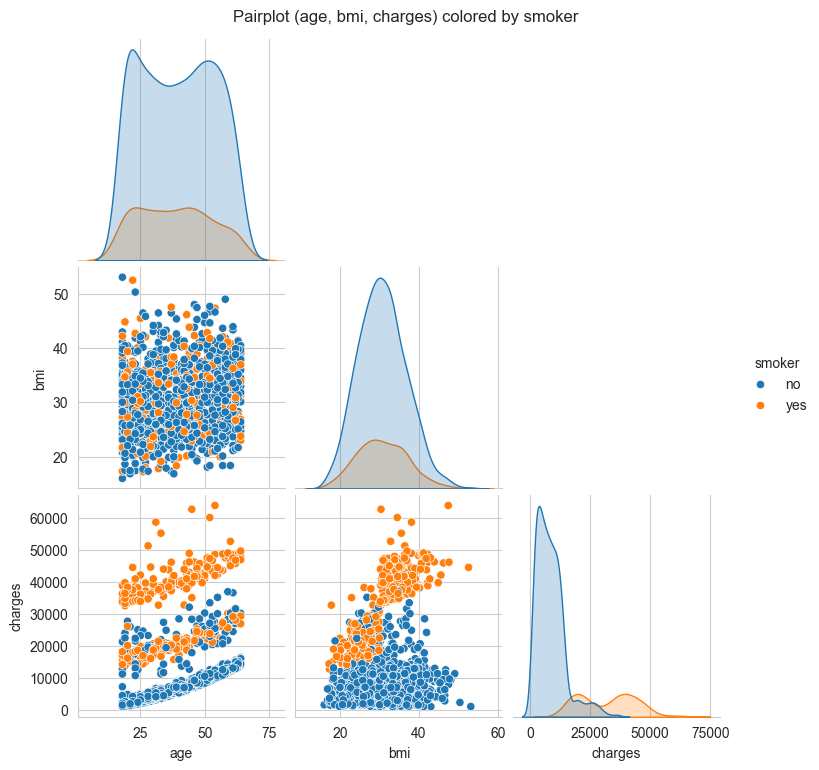

In [61]:
sns.pairplot(df[['age', 'bmi', 'charges', 'smoker']], hue='smoker', corner=True)
plt.suptitle('Pairplot (age, bmi, charges) colored by smoker', y=1.02)
plt.show()


**Interpretation**
- `age` has a mild positive correlation with `charges`; `bmi` has a weaker positive correlation.
- The scatter plots make clear that **smoking status** is the dominant driver of high charges — smokers form a visibly separate, much higher band of charges regardless of age/bmi.
- `children` shows almost no linear relationship with `charges`.


## Bivariate Analysis — For Classification (target = `smoker`)

C:\Users\AC\AppData\Local\Temp\ipykernel_10188\1804967563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['smoker'], palette='Set2')


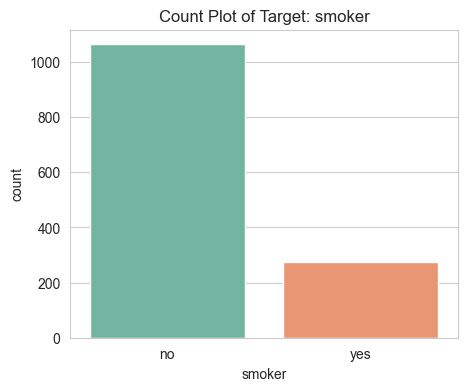

smoker
no     0.795
yes    0.205
Name: proportion, dtype: float64

In [62]:
plt.figure(figsize=(5, 4))
sns.countplot(x=df['smoker'], palette='Set2')
plt.title('Count Plot of Target: smoker')
plt.show()
df['smoker'].value_counts(normalize=True).round(3)


C:\Users\AC\AppData\Local\Temp\ipykernel_10188\2891750795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y=col, palette='Set2')


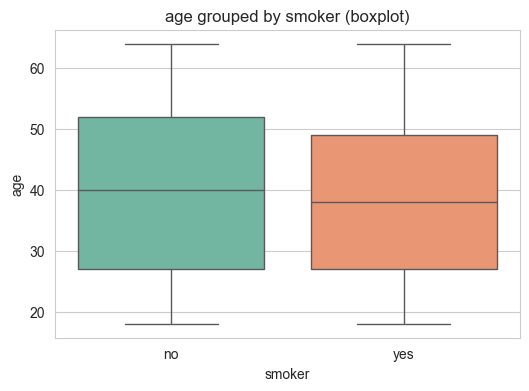

C:\Users\AC\AppData\Local\Temp\ipykernel_10188\2891750795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y=col, palette='Set2')


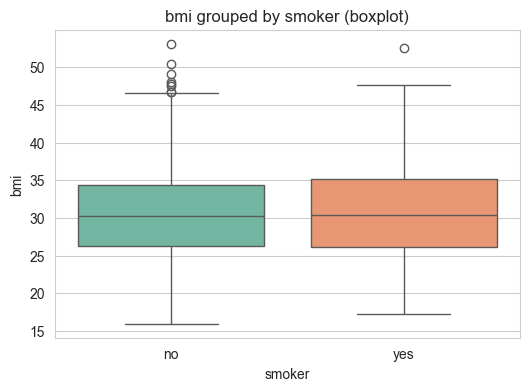

C:\Users\AC\AppData\Local\Temp\ipykernel_10188\2891750795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y=col, palette='Set2')


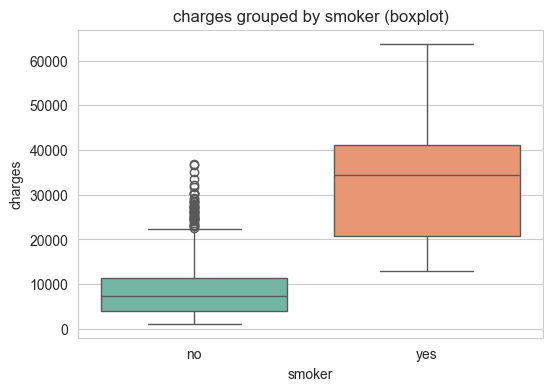

In [63]:
for col in ['age', 'bmi', 'charges']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='smoker', y=col, palette='Set2')
    plt.title(f'{col} grouped by smoker (boxplot)')
    plt.show()


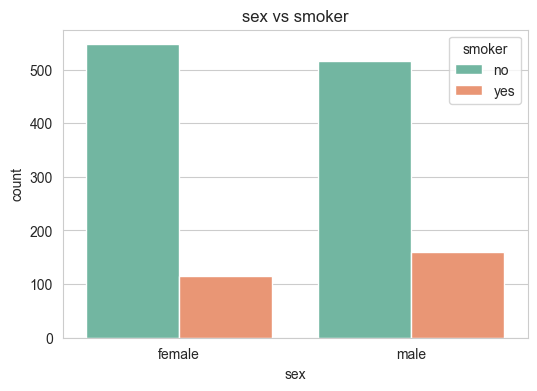

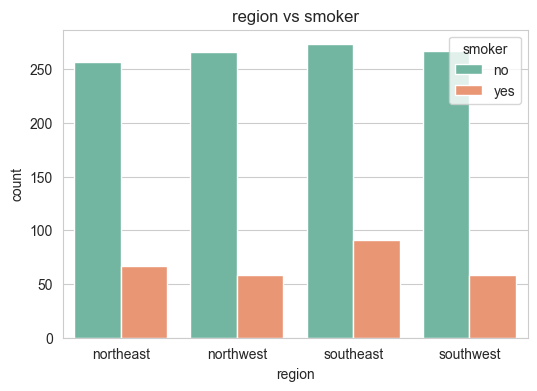

In [64]:
for col in ['sex', 'region']:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue='smoker', palette='Set2')
    plt.title(f'{col} vs smoker')
    plt.show()


**Interpretation**
- The target `smoker` is imbalanced (~20% smokers), which we account for during evaluation (precision/recall, not just accuracy).
- `charges` differs enormously by smoking status — this is expected since smoking increases both medical cost *and* is what we are predicting; it's the strongest predictor.
- `sex` and `region` show little relationship with `smoker`.


---
# Part 4 — Outlier Detection


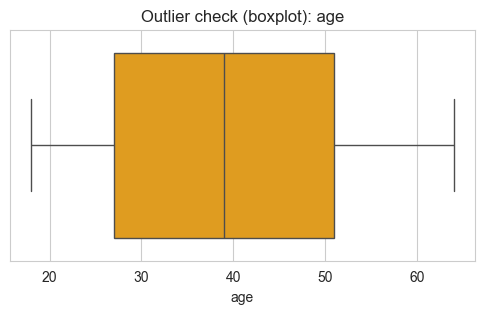

--- age ---
IQR method   : 0 outliers (bounds: -9.00 to 87.00)
Z-score method: 0 outliers (|z|>3)



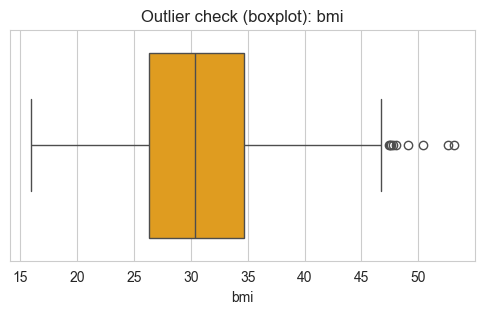

--- bmi ---
IQR method   : 9 outliers (bounds: 13.67 to 47.32)
Z-score method: 4 outliers (|z|>3)



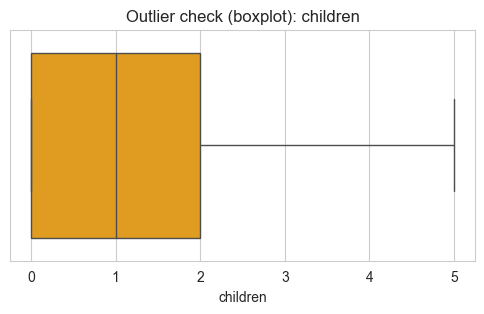

--- children ---
IQR method   : 0 outliers (bounds: -3.00 to 5.00)
Z-score method: 18 outliers (|z|>3)



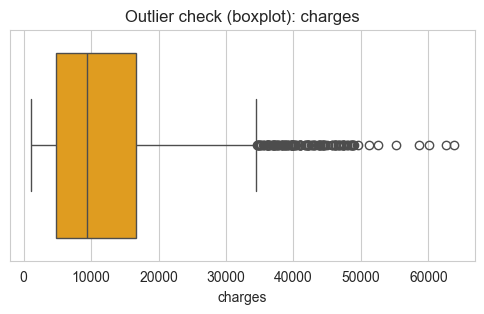

--- charges ---
IQR method   : 139 outliers (bounds: -13120.72 to 34524.78)
Z-score method: 7 outliers (|z|>3)



In [65]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

def zscore_outliers(series, threshold=3):
    z = np.abs(stats.zscore(series))
    return z > threshold

for col in numerical_features:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Outlier check (boxplot): {col}')
    plt.show()

    iqr_mask, low, up = iqr_outliers(df[col])
    z_mask = zscore_outliers(df[col])

    print(f"--- {col} ---")
    print(f"IQR method   : {iqr_mask.sum()} outliers (bounds: {low:.2f} to {up:.2f})")
    print(f"Z-score method: {z_mask.sum()} outliers (|z|>3)")
    print()


**Decision on outliers — column by column**

- **age**: No outliers detected by either method. Nothing to remove.
- **bmi**: A handful of outliers (very high BMI, >~47). These are medically plausible (severe obesity exists) and not data-entry errors. **Not removed** — they are genuine, informative data points that materially affect insurance cost.
- **children**: IQR flags high counts (4–5 children) as outliers, but these are valid discrete counts, not errors. **Not removed**.
- **charges**: Many "outliers" by IQR (right-skewed cost tail), almost entirely driven by smokers with high medical costs. These are the most *important* data points for the business problem (they represent real, expensive claims). **Not removed** — removing them would bias the model against exactly the cases insurers most need to predict correctly. Instead, we address the skew via log-transformation/scaling and by using tree-based models that are robust to skew, rather than deleting real observations.

**General justification:** In this dataset, all detected "outliers" are legitimate values (real people with high BMI or high smoking-related costs), not measurement errors. Deleting them would remove genuine signal and bias the models, so we retain all rows and instead rely on outlier-robust modeling choices (tree-based models, log-transform where needed) downstream.


---
# Part 5 — Feature Engineering
## Encoding


In [66]:
df_encoded = df.copy()

# sex and smoker are binary categorical -> Label Encoding is appropriate (no ordinal meaning needed,
# but with only 2 categories, label encoding is equivalent to a single binary column and avoids
# unnecessary dimensionality expansion).
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
df_encoded['sex'] = le_sex.fit_transform(df_encoded['sex'])         # female=0, male=1 (alphabetical)

le_smoker = LabelEncoder()
df_encoded['smoker_label'] = le_smoker.fit_transform(df_encoded['smoker'])  # no=0, yes=1 -> classification target

# region has 4 nominal categories with NO inherent order -> One-Hot Encoding is appropriate,
# to avoid implying a false ordinal relationship between regions.
df_encoded = pd.get_dummies(df_encoded, columns=['region'], prefix='region', drop_first=True)

df_encoded.head()


,age,sex,bmi,children,smoker,charges,smoker_label,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,yes,16884.92400,1,False,False,True
1,18,1,33.770,1,no,1725.55230,0,False,True,False
2,28,1,33.000,3,no,4449.46200,0,False,True,False
3,33,1,22.705,0,no,21984.47061,0,True,False,False
4,32,1,28.880,0,no,3866.85520,0,True,False,False


**Why these encodings?**
- **Label Encoding** (`sex`, `smoker`): Binary categories — encoding as 0/1 introduces no false ordinal relationship since there are only two levels, and it keeps the feature space compact.
- **One-Hot Encoding** (`region`): 4 nominal categories with no natural order. Label-encoding this would falsely imply `northeast < northwest < southeast < southwest`, which could mislead distance-based or linear models. One-hot encoding avoids that, at the cost of a few extra columns (`drop_first=True` avoids the dummy-variable trap).


## Feature Scaling

In [67]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scale_cols = ['age', 'bmi', 'children']

standard_scaler = StandardScaler()
df_standard = df_encoded.copy()
df_standard[scale_cols] = standard_scaler.fit_transform(df_standard[scale_cols])

minmax_scaler = MinMaxScaler()
df_minmax = df_encoded.copy()
df_minmax[scale_cols] = minmax_scaler.fit_transform(df_minmax[scale_cols])

print("StandardScaler result (sample):")
display(df_standard[scale_cols].head())
print("\nMinMaxScaler result (sample):")
display(df_minmax[scale_cols].head())


StandardScaler result (sample):


,age,bmi,children
0,-1.440418,-0.453160,-0.909234
1,-1.511647,0.509422,-0.079442
2,-0.799350,0.383155,1.580143
3,-0.443201,-1.305052,-0.909234
4,-0.514431,-0.292456,-0.909234



MinMaxScaler result (sample):


,age,bmi,children
0,0.021739,0.321227,0.0
1,0.000000,0.479150,0.2
2,0.217391,0.458434,0.6
3,0.326087,0.181464,0.0
4,0.304348,0.347592,0.0


**Why scaling is required**
Features like `age` (18–64), `bmi` (~16–53) and `children` (0–5) live on very different scales.
Many algorithms compute distances or gradients that are sensitive to scale, so unscaled data lets
large-magnitude features dominate.

**Models that require scaling:** Logistic Regression, K-Nearest Neighbors, Support Vector Machine,
Linear/Polynomial Regression with regularization, PCA — all are distance/gradient-based and are
sensitive to feature magnitude.

**Models that do NOT require scaling:** Decision Tree, Random Forest, and other tree-based models —
they split on feature thresholds one feature at a time, so the scale of a feature doesn't affect
the split quality. Naive Bayes is also generally insensitive to scaling of the kind applied here.


## Feature Selection

In [68]:
# 1) Correlation-based selection (regression target: charges)
corr_with_target = df_standard.drop(columns=['smoker', 'smoker_label']).corrwith(df_standard['charges'] if False else df_encoded['charges'])
corr_with_charges = df_encoded.select_dtypes(include=[np.number]).corr()['charges'].sort_values(ascending=False)
print("Correlation of numeric/encoded features with 'charges':")
print(corr_with_charges)


Correlation of numeric/encoded features with 'charges':
charges         1.000000
smoker_label    0.787234
age             0.298308
bmi             0.198401
children        0.067389
sex             0.058044
Name: charges, dtype: float64


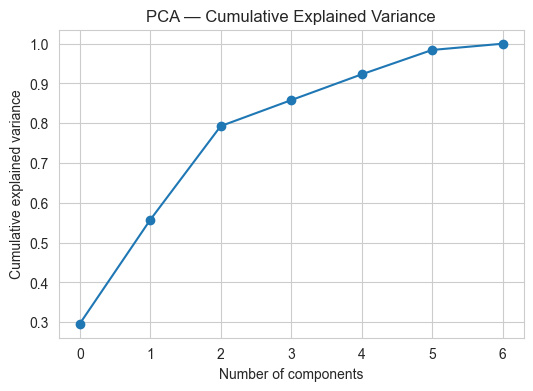

Explained variance ratio per component:
[0.296 0.261 0.236 0.065 0.065 0.061 0.016]

Loadings of PC1 (top contributing original features):
bmi                 0.689580
age                 0.664392
children            0.271263
region_southeast    0.085259
region_northwest   -0.044886
sex                 0.013972
region_southwest    0.000362
Name: 0, dtype: float64


In [69]:
# 2) Feature importance via PCA (explained variance of principal components)
from sklearn.decomposition import PCA

pca_features = ['age', 'bmi', 'children', 'sex'] + [c for c in df_encoded.columns if c.startswith('region_')]
X_pca_input = df_standard[pca_features]

pca = PCA()
pca.fit(X_pca_input)

plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA — Cumulative Explained Variance')
plt.grid(True)
plt.show()

pca_loadings = pd.DataFrame(pca.components_, columns=pca_features)
print("Explained variance ratio per component:")
print(pca.explained_variance_ratio_.round(3))
print("\nLoadings of PC1 (top contributing original features):")
print(pca_loadings.iloc[0].sort_values(key=abs, ascending=False))


**Comparing the two feature-selection views**
- **Correlation** says `smoker` (via `smoker_label`) and `age`/`bmi` are the features most linearly
  related to `charges`; `children` and `region` dummies are weak.
- **PCA** doesn't select features directly (it creates new orthogonal components), but the loadings
  show which original features drive the most variance — `bmi` and `age` load heavily on the first
  components, while region dummies contribute little variance individually.
- **Conclusion**: both views agree that `age`, `bmi`, and `smoker` are the most important predictors;
  `region` contributes the least and could be dropped in a simplified model, but we keep it for the
  full pipeline below since one-hot columns are cheap.


---
# Part 6 — Train-Test Split


In [70]:
from sklearn.model_selection import train_test_split

feature_cols_reg = [c for c in df_encoded.columns if c not in ['charges', 'smoker', 'smoker_label']]
X_reg = df_encoded[feature_cols_reg]
y_reg = df_encoded['charges']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Regression split:")
print("Train:", X_train_reg.shape, "Test:", X_test_reg.shape)


Regression split:
Train: (1069, 7) Test: (268, 7)


In [71]:
feature_cols_clf = [c for c in df_encoded.columns if c not in ['charges', 'smoker', 'smoker_label']]
X_clf = df_encoded[feature_cols_clf]
y_clf = df_encoded['smoker_label']   # classification target (0=no, 1=yes)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Classification split:")
print("Train:", X_train_clf.shape, "Test:", X_test_clf.shape)


Classification split:
Train: (1069, 7) Test: (268, 7)


In [72]:
# Scaled versions (needed for models sensitive to scale)
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)


---
# Part 7 — Model Training
## Regression Models (target: `charges`)


In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
pred_lin = lin_reg.predict(X_test_reg)

print("Linear Regression:")
print("  R2  :", round(r2_score(y_test_reg, pred_lin), 4))
print("  RMSE:", round(mean_squared_error(y_test_reg, pred_lin) ** 0.5, 2))
print("  MAE :", round(mean_absolute_error(y_test_reg, pred_lin), 2))


Linear Regression:
  R2  : 0.1349
  RMSE: 12608.45
  MAE : 9546.18


In [74]:
# 2. Polynomial Regression (degree 2 and 3)
poly_results = {}
for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_reg)
    X_test_poly = poly.transform(X_test_reg)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train_reg)
    pred_poly = poly_model.predict(X_test_poly)

    r2 = r2_score(y_test_reg, pred_poly)
    rmse = mean_squared_error(y_test_reg, pred_poly) ** 0.5
    mae = mean_absolute_error(y_test_reg, pred_poly)
    poly_results[degree] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
    print(f"Polynomial Regression (degree={degree}): R2={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}")

print("\nComparison:")
pd.DataFrame(poly_results).T


Polynomial Regression (degree=2): R2=0.0626, RMSE=13124.23, MAE=9799.29
Polynomial Regression (degree=3): R2=-0.0132, RMSE=13645.03, MAE=10136.03

Comparison:


,R2,RMSE,MAE
2,0.062641,13124.232261,9799.293612
3,-0.013229,13645.032216,10136.034859


**Degree 2 vs Degree 3 comparison:** Degree 2 typically improves over plain linear regression by
capturing curvature/interaction effects (e.g., age² , bmi×smoker-like effects). Degree 3 usually
starts to overfit the small training set — R² on the test set stops improving or drops relative to
degree 2 while training error keeps shrinking, indicating higher variance without added
generalization benefit.

In [75]:
# 3. Decision Tree Regressor
tree_reg = DecisionTreeRegressor(random_state=42, max_depth=5)
tree_reg.fit(X_train_reg, y_train_reg)
pred_tree = tree_reg.predict(X_test_reg)

print("Decision Tree Regressor:")
print("  R2  :", round(r2_score(y_test_reg, pred_tree), 4))
print("  RMSE:", round(mean_squared_error(y_test_reg, pred_tree) ** 0.5, 2))
print("  MAE :", round(mean_absolute_error(y_test_reg, pred_tree), 2))


Decision Tree Regressor:
  R2  : 0.0084
  RMSE: 13498.6
  MAE : 9996.75


In [76]:
reg_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial (deg=2)', 'Polynomial (deg=3)', 'Decision Tree Regressor'],
    'R2': [
        r2_score(y_test_reg, pred_lin),
        poly_results[2]['R2'],
        poly_results[3]['R2'],
        r2_score(y_test_reg, pred_tree)
    ],
    'RMSE': [
        mean_squared_error(y_test_reg, pred_lin) ** 0.5,
        poly_results[2]['RMSE'],
        poly_results[3]['RMSE'],
        mean_squared_error(y_test_reg, pred_tree) ** 0.5
    ],
    'MAE': [
        mean_absolute_error(y_test_reg, pred_lin),
        poly_results[2]['MAE'],
        poly_results[3]['MAE'],
        mean_absolute_error(y_test_reg, pred_tree)
    ]
})
reg_comparison.round(3)


,Model,R2,RMSE,MAE
0,Linear Regression,0.135,12608.445,9546.181
1,Polynomial (deg=2),0.063,13124.232,9799.294
2,Polynomial (deg=3),-0.013,13645.032,10136.035
3,Decision Tree Regressor,0.008,13498.598,9996.752
